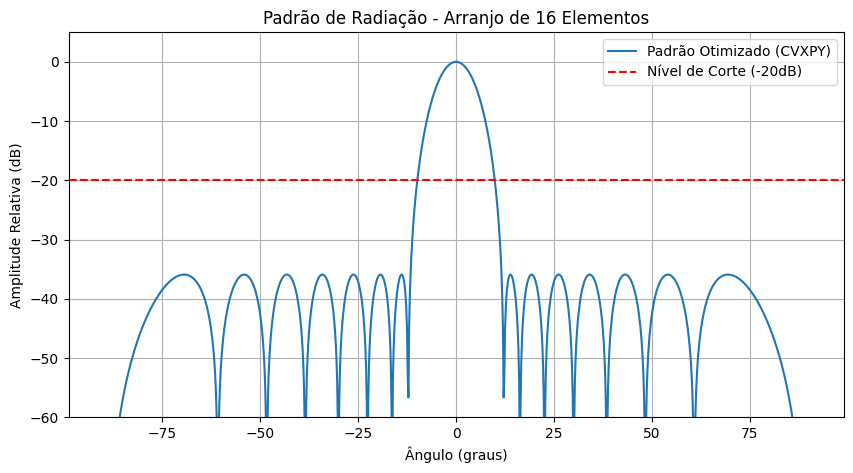

In [1]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt

# 1. Configurações do Arranjo
N = 16 # Número de elementos
theta = np.linspace(-np.pi/2, np.pi/2, 1000)  # De -90 a 90 graus
theta_deg = np.degrees(theta)

# Parâmetros do Lóbulo
target_angle = 0  # Onde o lóbulo principal deve apontar (rad)
null_width = 0.2  # Largura da zona do lóbulo principal

# 2. Matriz de Direção (Steering Matrix)
# d = lambda/2 -> fase = n * pi * sin(theta)
A_mat = np.exp(1j * np.outer(np.sin(theta), np.pi * np.arange(N)))

# 3. Definição do Problema no CVXPY
w = cp.Variable(N, complex=True)

# Índices para o lóbulo principal e lóbulos secundários
main_idx = np.abs(theta - target_angle) <= null_width
side_idx = np.abs(theta - target_angle) > null_width

# Objetivo: Minimizar o ganho nos lóbulos secundários (Side Lobe Level)
objective = cp.Minimize(cp.norm(A_mat[side_idx] @ w, "inf"))

# Restrição: Ganho unitário na direção desejada
constraints = [A_mat[np.argmin(np.abs(theta - target_angle))] @ w == 1]

prob = cp.Problem(objective, constraints)
prob.solve()

# 4. Cálculo da Resposta e Plotagem
pattern = np.abs(A_mat @ w.value)
pattern_db = 20 * np.log10(pattern / np.max(pattern)) # Normalizando em dB



plt.figure(figsize=(10, 5))
plt.plot(theta_deg, pattern_db, label='Padrão Otimizado (CVXPY)')
plt.axhline(-20, color='red', linestyle='--', label='Nível de Corte (-20dB)')
plt.title(f'Padrão de Radiação - Arranjo de {N} Elementos')
plt.xlabel('Ângulo (graus)')
plt.ylabel('Amplitude Relativa (dB)')
plt.grid(True)
plt.ylim([-60, 5])
plt.legend()
plt.show()

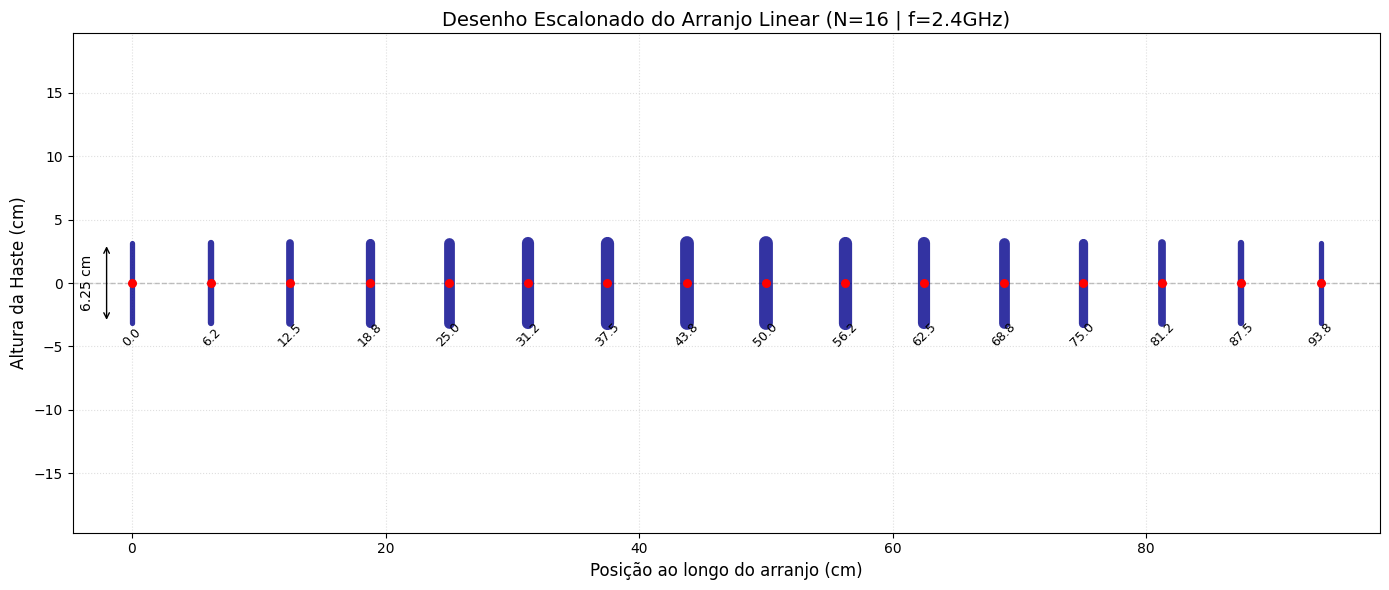

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configurações Físicas (Frequência 2.4 GHz) ---
f = 2.4e9
c = 3e8
lambd_cm = (c / f) * 100 # Comprimento de onda em cm (~12.5cm)
N = 16
espacamento = lambd_cm / 2 # d = 6.25 cm
altura_haste = lambd_cm / 2 # L = 6.25 cm

# Simulando a curva de amplitude do CVXPY (Janela de Chebyshev)
# As antenas do centro recebem mais corrente que as das pontas
x_norm = np.linspace(-1, 1, N)
amplitudes = np.exp(-1.5 * x_norm**2) # Curva de distribuição de potência

# --- Desenho Técnico 2D ---
plt.figure(figsize=(14, 6))

for i in range(N):
    x_pos = i * espacamento
    amp = amplitudes[i]

    # Desenha a Haste (Dipolo)
    # A cor e a espessura indicam a "força" do sinal em cada elemento
    plt.plot([x_pos, x_pos], [-altura_haste/2, altura_haste/2],
             color='darkblue', lw=2 + (amp * 8), alpha=0.8, solid_capstyle='round')

    # Ponto de alimentação (Conexão do cabo)
    plt.scatter(x_pos, 0, color='red', s=30, zorder=3)

    # Rótulo de posição em cm no eixo X
    plt.text(x_pos, -altura_haste*0.8, f'{x_pos:.1f}',
             ha='center', fontsize=9, rotation=45)

# Linha de base (Suporte/Boom)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=1)

# Dimensões e Estética
plt.title(f'Desenho Escalonado do Arranjo Linear (N={N} | f=2.4GHz)', fontsize=14)
plt.xlabel('Posição ao longo do arranjo (cm)', fontsize=12)
plt.ylabel('Altura da Haste (cm)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.4)
plt.axis('equal')

# Adiciona cota de altura na primeira haste
plt.annotate('', xy=(-2, -altura_haste/2), xytext=(-2, altura_haste/2),
             arrowprops=dict(arrowstyle='<->', color='black'))
plt.text(-3, 0, f'{altura_haste:.2f} cm', va='center', ha='right', rotation=90)

plt.tight_layout()
plt.show()